In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
def verlet(f, x, y, y_prev, h):
    return 2*y - y_prev + f(x, y)*h**2

def velocity_verlet(f, x, y, v, h):
    y_new = y + v*h + 0.5*f(x, y)*h**2
    v_new = v + 0.5*(f(x, y) + f(x + h, y_new))*h
    return y_new, v_new

def rk4(f, x, y, h):
    k1 = h * f(x, y)
    k2 = h * f(x + h/2, y + k1/2)
    k3 = h * f(x + h/2, y + k2/2)
    k4 = h * f(x + h, y + k3)
    return y + (k1 + 2*k2 + 2*k3 + k4)/6

def solve_verlet(accel, y0, v0, ts, h):
    N = len(ts)
    ys = np.zeros(N)
    ys[0] = y0
    ys[1] = y0 + v0*h + 0.5*accel(ts[0], y0)*h**2
    for i in range(2, N):
        ys[i] = verlet(accel, ts[i], ys[i-1], ys[i-2], h)
    return ys

def solve_vverlet(accel, y0, v0, ts, h):
    N = len(ts)
    ys = np.zeros(N)
    vs = np.zeros(N)
    ys[0] = y0
    vs[0] = v0
    for i in range(N-1):
        ys[i+1], vs[i+1] = velocity_verlet(accel, ts[i], ys[i], vs[i], h)
    return ys, vs

def solve_rk4_coupled(f, state0, ts, h):
    N = len(ts)
    states = np.zeros((N, len(state0)))
    states[0] = state0
    for i in range(N-1):
        states[i+1] = rk4(f, ts[i], states[i], h)
    return states

## Question 1

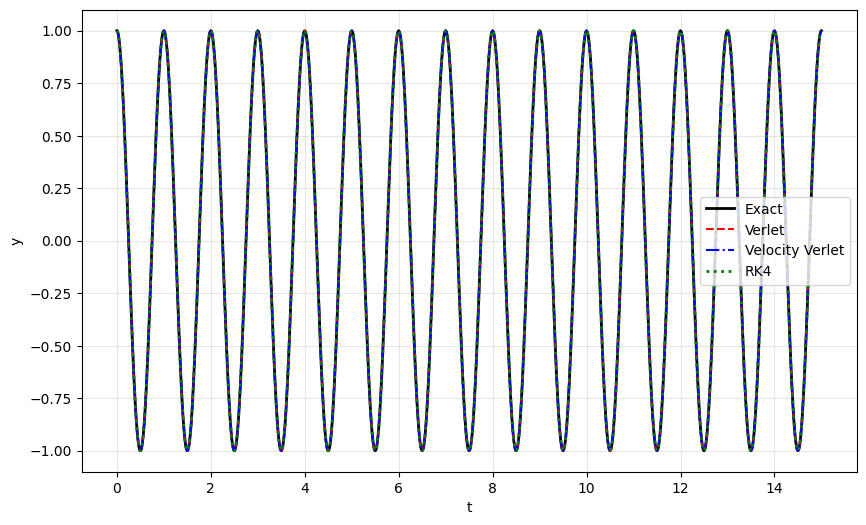

In [3]:
def accel_q1(t, y):
    return -4 * np.pi**2 * y

def rhs_q1(t, state):
    return np.array([state[1], -4 * np.pi**2 * state[0]])

h = 0.01
t0 = 0.0
tf = 15.0
y0 = 1.0
v0 = 0.0

ts = np.arange(t0, tf + h, h)

ys_v = solve_verlet(accel_q1, y0, v0, ts, h)
ys_vv, vs_vv = solve_vverlet(accel_q1, y0, v0, ts, h)
states_rk4 = solve_rk4_coupled(rhs_q1, np.array([y0, v0]), ts, h)

y_exact = np.cos(2 * np.pi * ts)

plt.figure(figsize=(10, 6))
plt.plot(ts, y_exact, 'k-', linewidth=2, label='Exact')
plt.plot(ts, ys_v, 'r--', label='Verlet')
plt.plot(ts, ys_vv, 'b-.', label='Velocity Verlet')
plt.plot(ts, states_rk4[:, 0], 'g:', linewidth=2, label='RK4')
plt.xlabel('t')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [4]:
h_vals = 10.0 ** np.arange(-4.0, -2.0 + 0.2, 0.2)

err_v = []
err_vv = []
err_rk4 = []

for h in h_vals:
    t_arr = np.arange(t0, tf + h, h)
    
    y_v = solve_verlet(accel_q1, y0, v0, t_arr, h)
    y_vv, _ = solve_vverlet(accel_q1, y0, v0, t_arr, h)
    st_rk4 = solve_rk4_coupled(rhs_q1, np.array([y0, v0]), t_arr, h)
    
    exact = np.cos(2 * np.pi * t_arr[-1])
    err_v.append(abs(y_v[-1] - exact))
    err_vv.append(abs(y_vv[-1] - exact))
    err_rk4.append(abs(st_rk4[-1, 0] - exact))

err_v = np.array(err_v)
err_vv = np.array(err_vv)
err_rk4 = np.array(err_rk4)

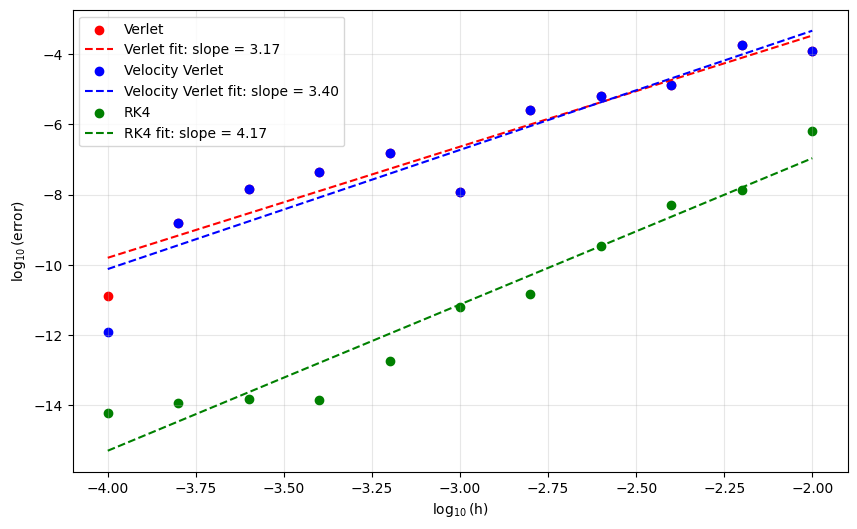

Verlet: error ∝ h^3.17
Velocity Verlet: error ∝ h^3.40
RK4: error ∝ h^4.17


In [5]:
log_h = np.log10(h_vals)
log_v = np.log10(err_v)
log_vv = np.log10(err_vv)
log_rk4 = np.log10(err_rk4)

def line(x, m, c):
    return m * x + c

pv, _ = curve_fit(line, log_h, log_v)
pvv, _ = curve_fit(line, log_h, log_vv)
prk4, _ = curve_fit(line, log_h, log_rk4)

plt.figure(figsize=(10, 6))
plt.scatter(log_h, log_v, color='red', label='Verlet')
plt.plot(log_h, line(log_h, *pv), 'r--', label=f'Verlet fit: slope = {pv[0]:.2f}')
plt.scatter(log_h, log_vv, color='blue', label='Velocity Verlet')
plt.plot(log_h, line(log_h, *pvv), 'b--', label=f'Velocity Verlet fit: slope = {pvv[0]:.2f}')
plt.scatter(log_h, log_rk4, color='green', label='RK4')
plt.plot(log_h, line(log_h, *prk4), 'g--', label=f'RK4 fit: slope = {prk4[0]:.2f}')
plt.xlabel(r'$\log_{10}$(h)')
plt.ylabel(r'$\log_{10}$(error)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f'Verlet: error ∝ h^{pv[0]:.2f}')
print(f'Velocity Verlet: error ∝ h^{pvv[0]:.2f}')
print(f'RK4: error ∝ h^{prk4[0]:.2f}')

## Question 2

In [4]:
m = 2.0
v0_mag = 10.0
theta = 60.0 * np.pi / 180
g = 9.8
gamma = 2.0

vx0 = v0_mag * np.cos(theta)
vy0 = v0_mag * np.sin(theta)

def projectile_rhs(t, state, gam):
    x, y, vx, vy = state
    return np.array([vx, vy, -gam/m * vx, -g - gam/m * vy])

def euler_step(f, t, state, h, gam):
    return state + h * f(t, state, gam)

def vverlet_projectile(f, state, h, gam):
    x, y, vx, vy = state
    ax = -gam/m * vx
    ay = -g - gam/m * vy
    
    x_new = x + vx*h + 0.5*ax*h**2
    y_new = y + vy*h + 0.5*ay*h**2
    vx_new = vx + 0.5*ax*h
    vy_new = vy + 0.5*ay*h
    
    ax_new = -gam/m * vx_new
    ay_new = -g - gam/m * vy_new
    
    vx_new = vx + 0.5*(ax + ax_new)*h
    vy_new = vy + 0.5*(ay + ay_new)*h
    
    return np.array([x_new, y_new, vx_new, vy_new])

def rk4_step(f, t, state, h, gam):
    k1 = h * f(t, state, gam)
    k2 = h * f(t + h/2, state + k1/2, gam)
    k3 = h * f(t + h/2, state + k2/2, gam)
    k4 = h * f(t + h, state + k3, gam)
    return state + (k1 + 2*k2 + 2*k3 + k4)/6

def simulate_projectile(method, gam, h=0.01):
    state = np.array([0.0, 0.0, vx0, vy0])
    t = 0.0
    trajectory = [state.copy()]
    
    while state[1] >= 0:
        if method == 'euler':
            state = euler_step(projectile_rhs, t, state, h, gam)
        elif method == 'vverlet':
            state = vverlet_projectile(projectile_rhs, state, h, gam)
        elif method == 'rk4':
            state = rk4_step(projectile_rhs, t, state, h, gam)
        t += h
        trajectory.append(state.copy())
        if t > 100:
            break
    
    return np.array(trajectory)

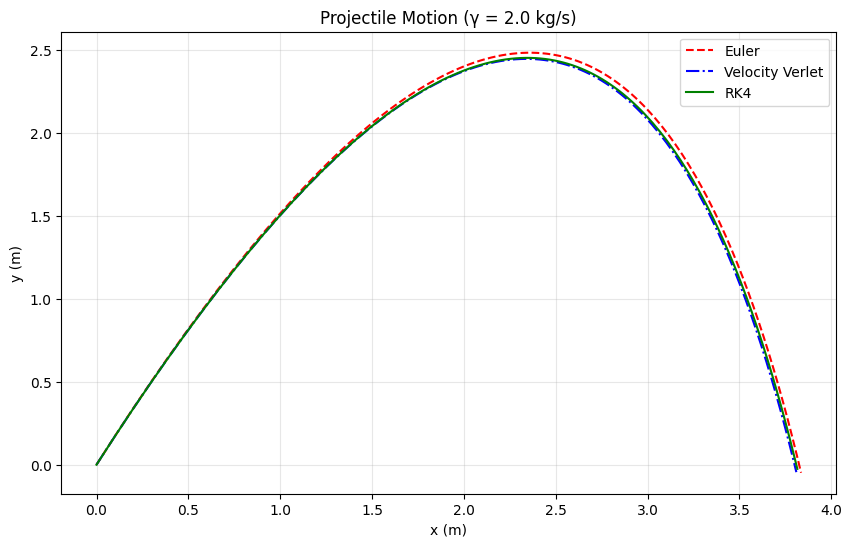

In [5]:
traj_e = simulate_projectile('euler', gamma)
traj_vv = simulate_projectile('vverlet', gamma)
traj_rk = simulate_projectile('rk4', gamma)

plt.figure(figsize=(10, 6))
plt.plot(traj_e[:, 0], traj_e[:, 1], 'r--', label='Euler')
plt.plot(traj_vv[:, 0], traj_vv[:, 1], 'b-.', label='Velocity Verlet')
plt.plot(traj_rk[:, 0], traj_rk[:, 1], 'g-', label='RK4')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title(f'Projectile Motion (γ = {gamma} kg/s)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

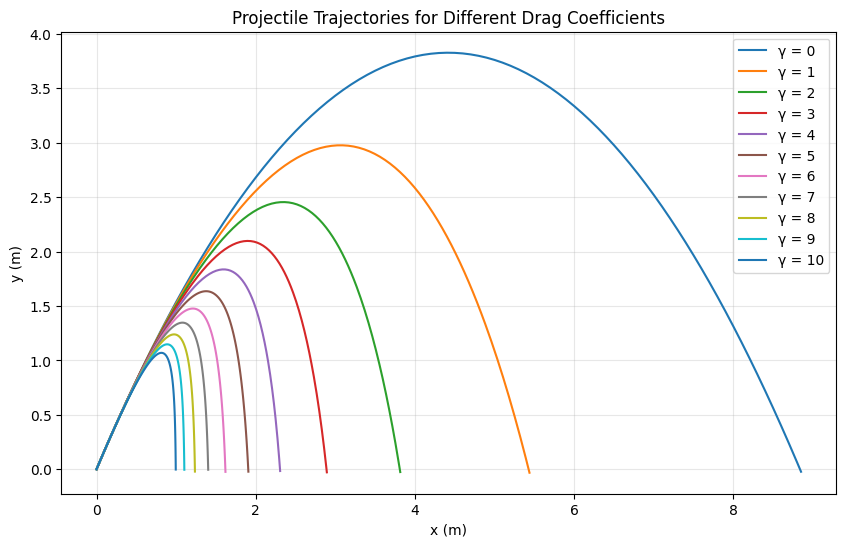

In [7]:
gamma_vals = np.arange(0, 11, 1)

plt.figure(figsize=(10, 6))
for gam in gamma_vals:
    traj = simulate_projectile('rk4', gam)
    plt.plot(traj[:, 0], traj[:, 1], label=f'γ = {gam}')

plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Projectile Trajectories for Different Drag Coefficients')
plt.legend()
plt.grid(alpha=0.3)
plt.show()